#Importações

In [79]:
# importações
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

#Carregar dados e ordenação

In [80]:

# carregar dados tratados
df = pd.read_excel('BASE_FINAL_TRATADA.xlsx')

# ordenação dos dados
df = df.sort_values(['Nome', 'Ano'])

#Dicionário de dados

| Coluna           | Descrição                                                     |
| ---------------- | ------------------------------------------------------------- |
| **Nome**         | Identificador anonimizado do aluno                            |
| **Ano**          | Ano da avaliação (2022, 2023, 2024)                           |
| **Data de Nasc** | Ano de nascimento do aluno                                    |
| **Idade**        | Idade do aluno no ano da avaliação                            |
| **Gênero**       | Sexo do aluno (Masculino/Feminino)                            |
| **Pedra**        | Fase educacional do aluno (Quartzo, Ágata, Ametista, Topázio) |
| **INDE**         | Índice geral de desempenho do aluno                           |
| **IAN**          | Índice de Adequação de Nível (mede defasagem)                 |
| **IDA**          | Índice de Desempenho Acadêmico                                |
| **IEG**          | Índice de Engajamento                                         |
| **IAA**          | Índice de Autoavaliação                                       |
| **IPS**          | Índice Psicossocial                                           |
| **IPP**          | Índice Psicopedagógico                                        |
| **IPV**          | Índice de Ponto de Virada                                     |
| **DELTA_IDA**    | Variação do desempenho acadêmico ao longo do tempo            |
| **DELTA_IEG**    | Variação do engajamento                                       |
| **DELTA_INDE**   | Variação da nota geral                                        |
| **ENG_X_DESEMP** | Interação entre engajamento e desempenho                      |
| **RISCO_FUTURO** | Variável alvo do modelo (1 = risco de defasagem futura)       |


#EDA

Visão geral da base

In [81]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 3030 entries, 0 to 1068
Data columns (total 48 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   RA                     3030 non-null   object 
 1   Fase                   3030 non-null   object 
 2   Turma                  3030 non-null   object 
 3   Nome                   3030 non-null   object 
 4   Data de Nasc           3030 non-null   int64  
 5   Idade                  2631 non-null   float64
 6   Gênero                 3030 non-null   object 
 7   Ano ingresso           3030 non-null   int64  
 8   Instituição de ensino  3029 non-null   object 
 9   Pedra                  2883 non-null   object 
 10  INDE                   2883 non-null   object 
 11  Cg                     860 non-null    float64
 12  Cf                     860 non-null    float64
 13  Ct                     860 non-null    float64
 14  Nº Av                  2954 non-null   float64
 15  Avaliador

,Data de Nasc,Idade,Ano ingresso,Cg,Cf,Ct,Nº Av,IAA,IEG,IPS,IDA,Mat,Por,Ing,IPV,IAN,Defasagem,Ano,IPP,Destaque IPV.1
count,3030.000000,2631.000000,3030.000000,860.000000,860.000000,860.000000,2954.000000,2865.000000,2954.000000,2859.000000,2852.000000,2846.000000,2845.000000,1091.000000,2852.000000,3030.000000,3030.000000,3030.00000,1992.000000,0.0
mean,2010.454455,12.548081,2021.563696,430.516279,75.519767,6.598837,3.031821,7.918225,7.945696,6.287129,6.375964,6.161595,6.430668,6.289413,7.545476,7.179043,-0.642904,2023.09769,7.555203,NaN
std,3.314445,3.283307,1.822171,248.432761,52.312670,3.975858,1.063670,2.626209,2.152281,1.792491,1.956637,2.398341,2.138916,2.732636,1.084347,2.535266,0.866382,0.80995,0.938990,NaN
min,1996.000000,7.000000,2016.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,2.500000,0.000000,0.000000,0.000000,0.000000,2.500000,2.500000,-5.000000,2022.00000,2.500000,NaN
25%,2008.000000,10.000000,2021.000000,215.750000,30.000000,3.000000,2.000000,7.900000,7.300000,5.020000,5.100000,4.800000,5.200000,4.500000,6.984000,5.000000,-1.000000,2022.00000,7.083333,NaN
50%,2011.000000,12.000000,2022.000000,430.500000,67.000000,6.000000,3.000000,8.751000,8.600000,7.500000,6.666667,6.300000,6.700000,6.700000,7.583000,5.000000,-1.000000,2023.00000,7.500000,NaN
75%,2013.000000,15.000000,2023.000000,645.250000,118.000000,9.000000,4.000000,9.500000,9.400000,7.510000,7.833333,8.000000,8.000000,8.500000,8.255000,10.000000,0.000000,2024.00000,8.125000,NaN
max,2017.000000,27.000000,2024.000000,862.000000,192.000000,18.000000,6.000000,10.002000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.010000,10.000000,3.000000,2024.00000,10.000000,NaN


A base apresenta dados de alunos ao longo de múltiplos anos, contendo indicadores acadêmicos, comportamentais e psicossociais. Não foram identificados grandes volumes de dados ausentes após o processo de limpeza.

Distribuição dos indicadores

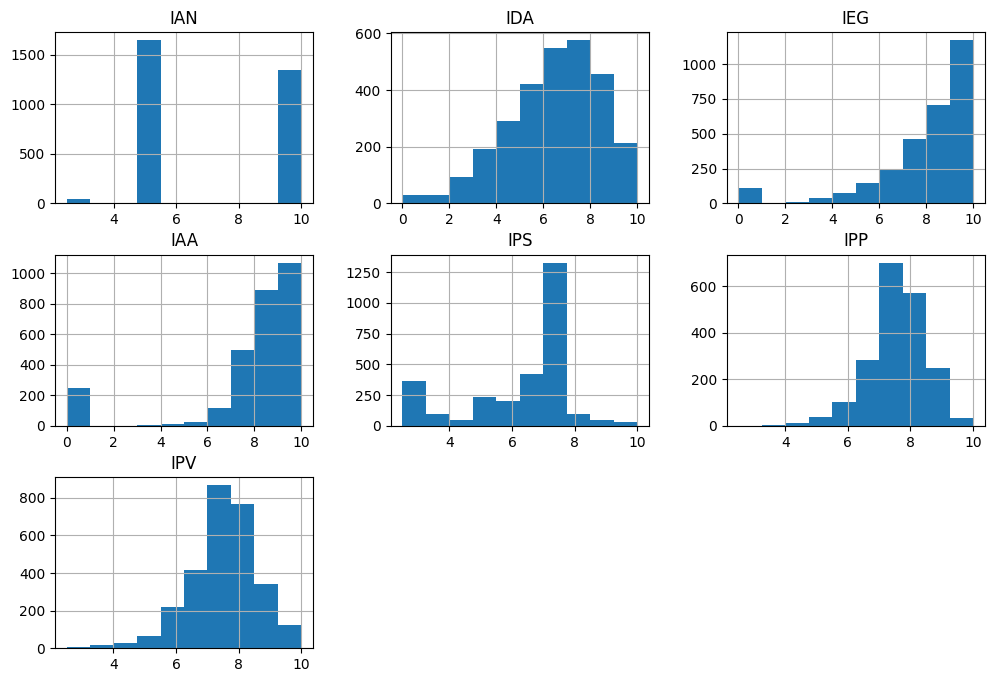

In [82]:
import matplotlib.pyplot as plt

df[['IAN','IDA','IEG','IAA','IPS','IPP','IPV','INDE']].hist(figsize=(12,8))
plt.show()

Observa-se a distribuição dos principais indicadores, permitindo identificar concentração dos valores e possíveis assimetrias. Alguns indicadores apresentam maior dispersão, sugerindo heterogeneidade no perfil dos alunos.

Correlação entre variáveis

/tmp/ipykernel_159/100414601.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace('INCLUIR', np.nan, inplace=True)


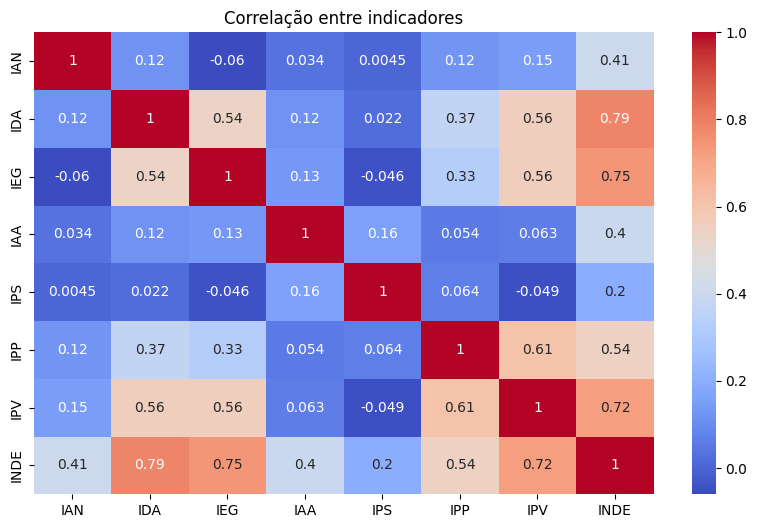

In [83]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

df.replace('INCLUIR', np.nan, inplace=True)
colunas = ['IAN','IDA','IEG','IAA','IPS','IPP','IPV','INDE']

for col in colunas:
    df[col] = pd.to_numeric(df[col], errors='coerce')

plt.figure(figsize=(10,6))
sns.heatmap(df[colunas].corr(), annot=True, cmap='coolwarm')
plt.title("Correlação entre indicadores")
plt.show()

Observa-se correlação positiva entre desempenho acadêmico (IDA), engajamento (IEG) e o índice geral (INDE), indicando que alunos mais engajados tendem a apresentar melhores resultados.
A análise também sugere que fatores psicossociais podem impactar indiretamente o desempenho.

Engajamento vs Desempenho

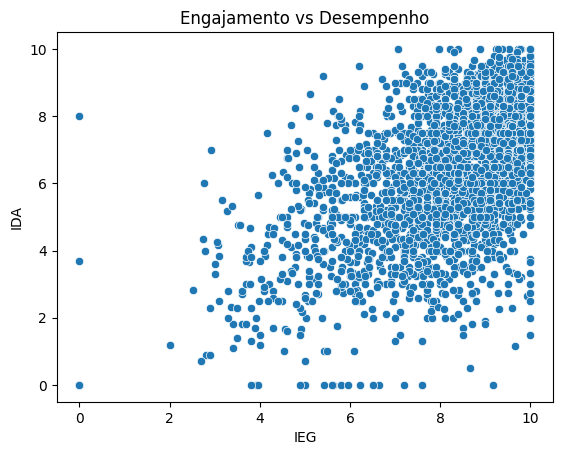

In [84]:
sns.scatterplot(data=df, x='IEG', y='IDA')
plt.title("Engajamento vs Desempenho")
plt.show()

Existe uma tendência positiva entre engajamento e desempenho acadêmico, indicando que alunos mais engajados tendem a apresentar melhores resultados escolares.

#Feature Engineering

In [85]:
# target
df['IAN_FUTURO'] = df.groupby('Nome')['IAN'].shift(-1)

# remover linhas sem futuro
df = df.dropna(subset=['IAN_FUTURO'])

# definir risco (mediana)
limite = df['IAN'].median()
df['RISCO_FUTURO'] = (df['IAN_FUTURO'] > limite).astype(int)

# variação ao longo do tempo
df['DELTA_IDA'] = df.groupby('Nome')['IDA'].diff()
df['DELTA_IEG'] = df.groupby('Nome')['IEG'].diff()
df['DELTA_INDE'] = df.groupby('Nome')['INDE'].diff()

# interação entre variáveis
df['ENG_X_DESEMP'] = df['IEG'] * df['IDA']

# preencher nulos gerados pelo diff
df.fillna(0, inplace=True)

/tmp/ipykernel_159/2990918063.py:20: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(0, inplace=True)


#Features

In [86]:
features = [
    'IDA','IEG','IAA','IPS','IPP','IPV','INDE',
    'DELTA_IDA','DELTA_IEG','DELTA_INDE',
    'ENG_X_DESEMP'
]

X = df[features]
y = df['RISCO_FUTURO']

#Treino e Teste

In [87]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

#Modelo

In [88]:
model = RandomForestClassifier(
    n_estimators=400,
    max_depth=12,
    min_samples_split=5,
    class_weight='balanced',
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=12,
                       min_samples_split=5, n_estimators=400, random_state=42)

#Previsão e Avaliação

Acurácia: 0.7372262773722628

Classification Report:

              precision    recall  f1-score   support

           0       0.71      0.78      0.74       135
           1       0.76      0.70      0.73       139

    accuracy                           0.74       274
   macro avg       0.74      0.74      0.74       274
weighted avg       0.74      0.74      0.74       274



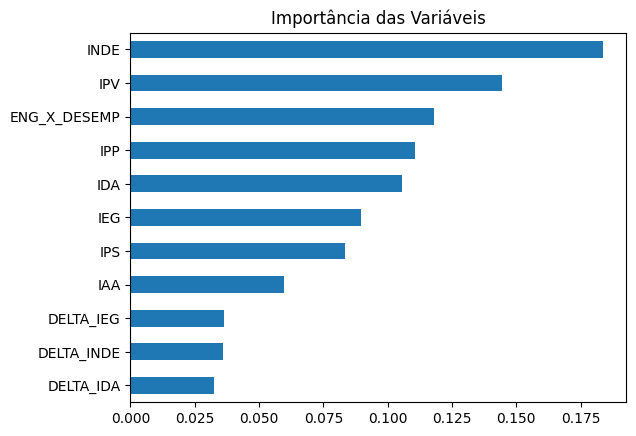

,IDA,IEG,IAA,IPS,IPP,IPV,INDE,DELTA_IDA,DELTA_IEG,DELTA_INDE,ENG_X_DESEMP,Real,Previsto
692,5.7,9.8,9.5,8.10,0.000000,7.667,7.944000,0.0,0.0,0.000000,55.86,1,1
1831,0.0,0.0,0.0,0.00,0.000000,0.000,0.000000,0.0,0.0,0.000000,0.00,1,1
1388,6.3,8.8,0.0,7.52,7.083333,7.840,6.548333,-2.5,-0.4,-1.623667,55.44,1,1
760,8.2,9.4,10.0,7.50,0.000000,8.250,8.060000,0.0,0.0,0.000000,77.08,0,1
1685,6.2,9.4,8.3,2.52,8.125000,8.420,7.695233,1.0,0.3,-0.096767,58.28,1,1


In [89]:
y_pred = model.predict(X_test)

# avaliação
print("Acurácia:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# importancia das variáveis
import matplotlib.pyplot as plt

importancias = pd.Series(model.feature_importances_, index=features)
importancias.sort_values().plot(kind='barh')

plt.title('Importância das Variáveis')
plt.show()

# resultado
df_resultado = X_test.copy()
df_resultado['Real'] = y_test
df_resultado['Previsto'] = y_pred

df_resultado.head()

#Modelo.pkl


In [90]:
import pickle

with open('modelo_risco.pkl', 'wb') as f:
    pickle.dump(model, f)